# Predicting Portfolio Values with Monte Carlo Analysis


In [25]:
import numpy as np
import yfinance as yf
import datetime as dt
import portfolio_value as pv
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import norm

In [6]:
funds = ['VBTLX', 'VOO']
start_date = dt.datetime(2025,1,1)
end_date = dt.datetime(2026,7,1)

fund_data = yf.download(funds, start=start_date, end=end_date)

[                       0%                       ]

[*********************100%***********************]  2 of 2 completed


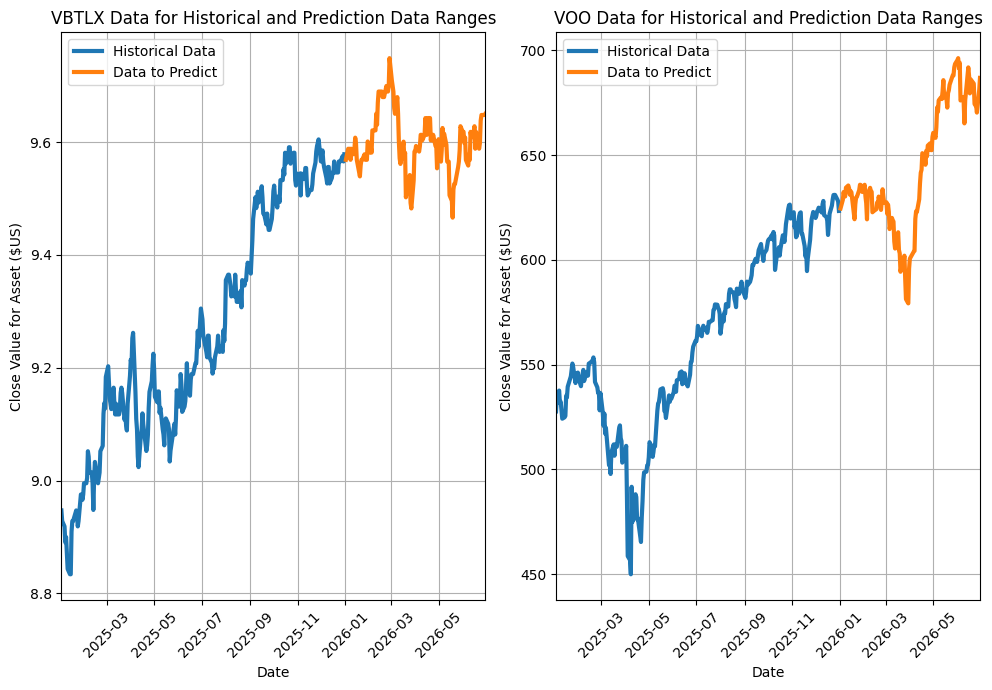

In [16]:
fig, ax = plt.subplots(1,2,figsize=(10,7))
for ii in range(2):
    ax[ii].plot(fund_data['Close'][funds[ii]]['2025-01-02':'2025-12-31'], linewidth=3, label='Historical Data')
    ax[ii].plot(fund_data['Close'][funds[ii]]['2026-01-01':'2026-7-1'], linewidth=3, label='Data to Predict')
    ax[ii].grid(); ax[ii].set_xlabel('Date'); ax[ii].set_ylabel('Close Value for Asset ($US)'); ax[ii].legend()
    ax[ii].set_xlim(left=min(fund_data['Close'][funds[ii]].index), right=max(fund_data['Close'][funds[ii]].index))
    ax[ii].tick_params(axis='x', labelrotation=45)
    ax[ii].set_title('{:} Data for Historical and Prediction Data Ranges'.format(funds[ii]))
fig.tight_layout()

In [ ]:
fund_allocations = {'VBTLX':0.4,
                    'VOO':0.6}
initial_value = 1000
bond_returns = fund_data['Close']['VBTLX']['2026-01-01':'2026-7-1'].pct_change().to_numpy()
stock_returns = fund_data['Close']['VOO']['2026-01-01':'2026-7-1'].pct_change().to_numpy()

bond_value = np.zeros(bond_returns.shape, dtype=float)
bond_value[0] = initial_value*fund_allocations['VBTLX']

stock_value = np.zeros(stock_returns.shape, dtype=float)
stock_value[0] = initial_value*fund_allocations['VOO']
for ii in range(1,stock_value.shape[0]):
    bond_value[ii] = bond_value[ii-1] + bond_returns[ii]*bond_value[ii-1]
    stock_value[ii] = stock_value[ii-1] + stock_returns[ii]*stock_value[ii-1]

total_value = bond_value + stock_value

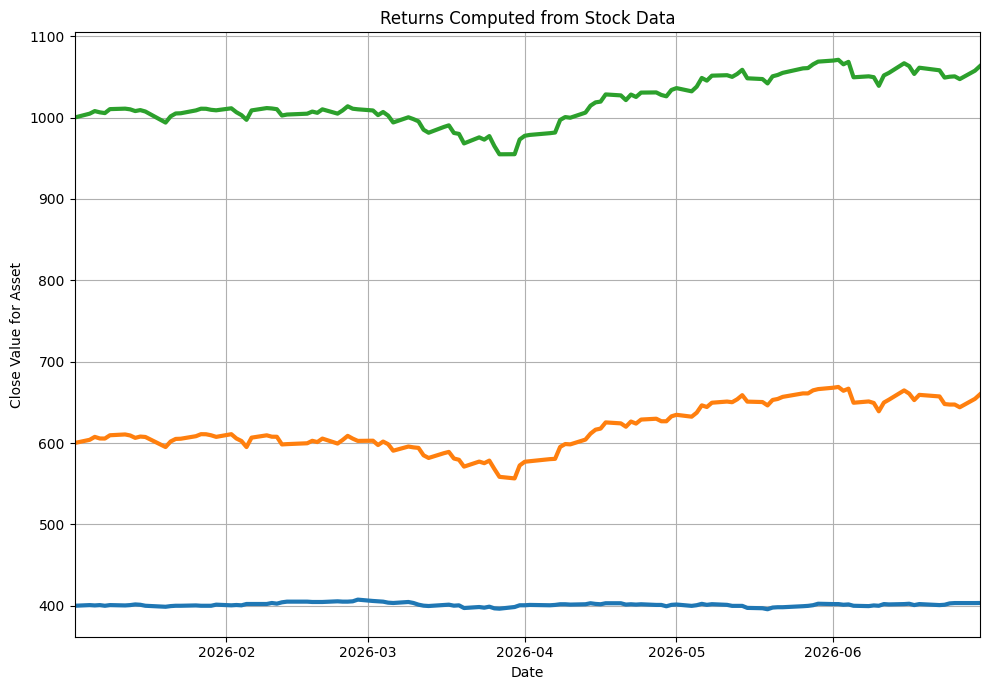

In [24]:
plt.figure(figsize=(10,7))
plt.plot(fund_data['2026-01-01':'2026-7-1'].index, bond_value, linewidth=3, label='Bond Index')
plt.plot(fund_data['2026-01-01':'2026-7-1'].index, stock_value, linewidth=3, label='Stock Index')
plt.plot(fund_data['2026-01-01':'2026-7-1'].index, total_value, linewidth=3, label='Total Value')
plt.grid(); plt.xlabel('Date'); plt.ylabel('Close Value for Asset');
plt.xlim(left=min(fund_data['2026-01-01':'2026-7-1'].index),
         right=max(fund_data['2026-01-01':'2026-7-1'].index))
plt.title('Returns Computed from Stock Data')
plt.tight_layout()

In [26]:
fund_data['Close']['2025-01-02':'2025-12-31']

Ticker,VBTLX,VOO
Date,,
2025-01-02,8.947142,527.721863
2025-01-03,8.928287,534.536255
2025-01-06,8.918858,537.648804
2025-01-07,8.890574,531.600403
2025-01-08,8.900001,532.317139
...,...,...
2025-12-24,9.565610,630.945190
2025-12-26,9.565610,631.004883
2025-12-29,9.575381,628.778320


In [45]:
allocations = pd.DataFrame({'VBTLX':[fund_allocations['VBTLX']*100, fund_allocations['VBTLX']*100],
                            'VOO':[fund_allocations['VOO']*100, fund_allocations['VOO']*100]}, 
                           index=[start_date,end_date])
fund_pv = pv.PortfolioValue(fund_data['Close']['2025-01-02':'2025-12-31'], allocations, initial_value)
fund_pv.predict_value_monte_carlo(start_date=dt.datetime(2026,1,1),
                                  end_date=dt.datetime(2026,7,1),
                                  number_of_realizations=10000)

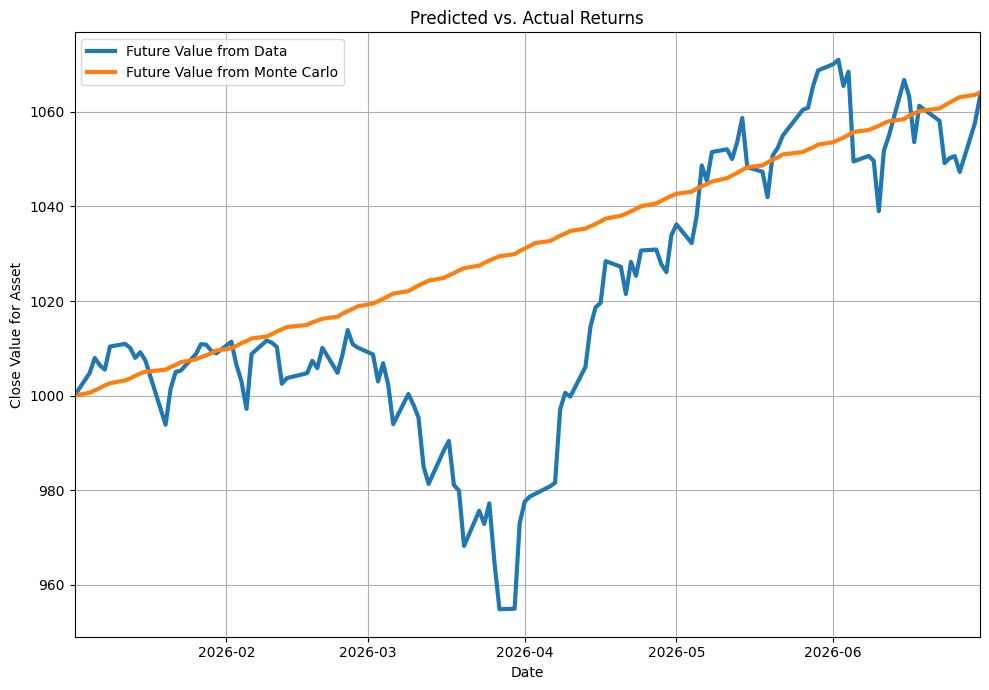

In [47]:
plt.figure(figsize=(10,7))
plt.plot(fund_data['2026-01-01':'2026-7-1'].index, total_value, linewidth=3, 
         label='Future Value from Data')
plt.plot(fund_pv.future_portfolio_expected_value()['Total'], 
         linewidth=3, label='Future Value from Monte Carlo')
plt.grid(); plt.xlabel('Date'); plt.ylabel('Close Value for Asset');
plt.xlim(left=min(fund_data['2026-01-01':'2026-7-1'].index),
         right=max(fund_data['2026-01-01':'2026-7-1'].index))
plt.title('Predicted vs. Actual Returns'); plt.legend()
plt.tight_layout()

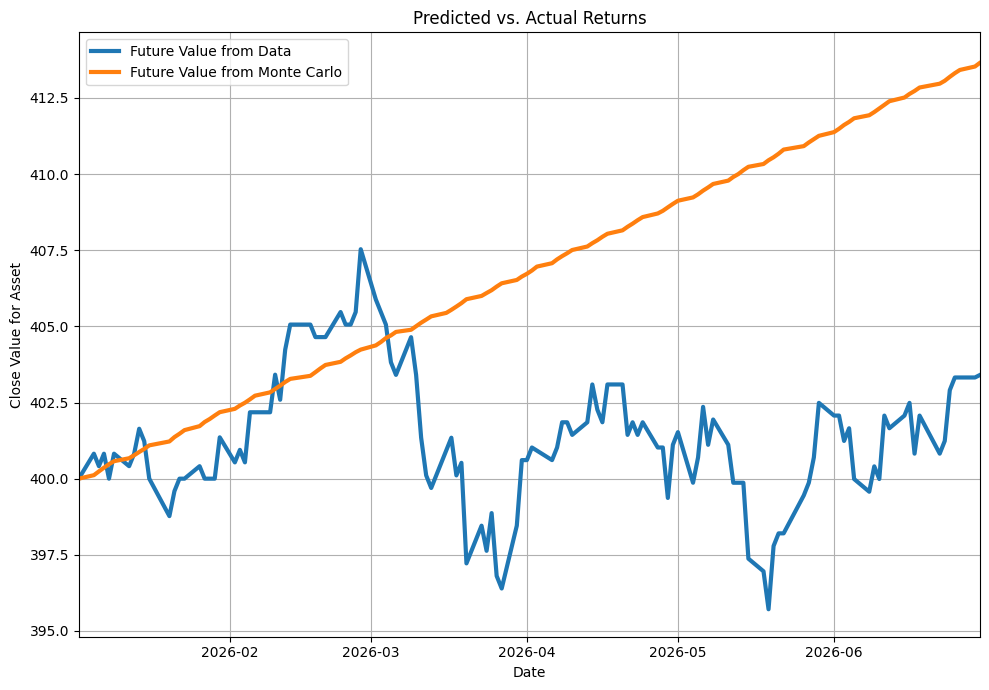

In [48]:
plt.figure(figsize=(10,7))
plt.plot(fund_data['2026-01-01':'2026-7-1'].index, bond_value, linewidth=3, 
         label='Future Value from Data')
plt.plot(fund_pv.future_portfolio_expected_value()['VBTLX'], 
         linewidth=3, label='Future Value from Monte Carlo')
plt.grid(); plt.xlabel('Date'); plt.ylabel('Close Value for Asset');
plt.xlim(left=min(fund_data['2026-01-01':'2026-7-1'].index),
         right=max(fund_data['2026-01-01':'2026-7-1'].index))
plt.title('Predicted vs. Actual Returns'); plt.legend()
plt.tight_layout()

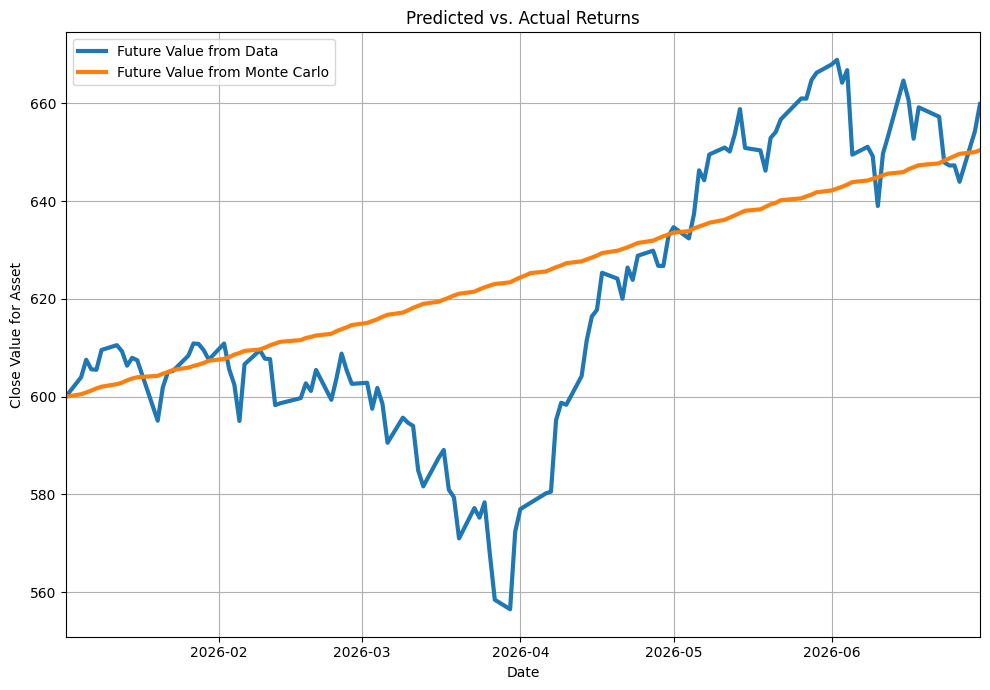

In [49]:
plt.figure(figsize=(10,7))
plt.plot(fund_data['2026-01-01':'2026-7-1'].index, stock_value, linewidth=3, 
         label='Future Value from Data')
plt.plot(fund_pv.future_portfolio_expected_value()['VOO'], 
         linewidth=3, label='Future Value from Monte Carlo')
plt.grid(); plt.xlabel('Date'); plt.ylabel('Close Value for Asset');
plt.xlim(left=min(fund_data['2026-01-01':'2026-7-1'].index),
         right=max(fund_data['2026-01-01':'2026-7-1'].index))
plt.title('Predicted vs. Actual Returns'); plt.legend()
plt.tight_layout()